<a href="https://colab.research.google.com/github/Aditigarg18/Aditigarg18/blob/main/traffic_demand.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print(train.shape)
print(test.shape)

print(train.head())
print(train.info())
print(train.describe())

(77299, 11)
(41778, 10)
   Index geohash  day timestamp    demand     RoadType  NumberofLanes  \
0      0  qp02z1   48       0:0  0.048804          NaN              1   
1      1  qp02zt   48       0:0  0.118507  Residential              3   
2      2  qp08bj   48       0:0  0.027132  Residential              1   
3      3  qp08gt   48       0:0  0.003272  Residential              1   
4      4  qp02zq   48       0:0  0.010819  Residential              1   

  LargeVehicles Landmarks  Temperature Weather  
0   Not Allowed        No          NaN     NaN  
1       Allowed       Yes    31.104565   Sunny  
2   Not Allowed        No    25.919267   Sunny  
3   Not Allowed        No          NaN   Rainy  
4   Not Allowed        No    10.803667   Rainy  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1

understanding the dataset.

In [ ]:
print(train.isnull().sum())
print(test.isnull().sum())

Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
dtype: int64
Index               0
geohash             0
day                 0
timestamp           0
RoadType          324
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      1349
Weather           431
dtype: int64


2. checking the target variable.

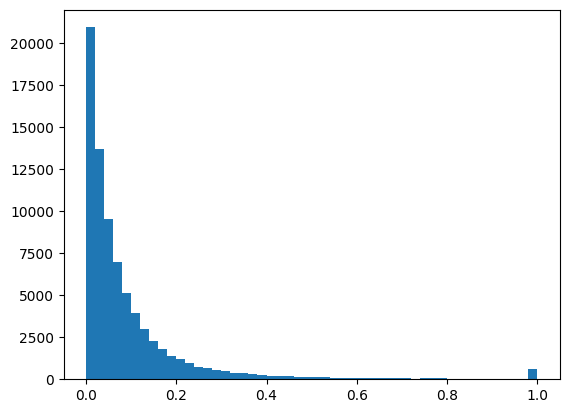

count    7.729900e+04
mean     9.394238e-02
std      1.421905e-01
min      6.245650e-07
25%      1.822723e-02
50%      4.775994e-02
75%      1.085951e-01
max      1.000000e+00
Name: demand, dtype: float64


In [ ]:
import matplotlib.pyplot as plt

plt.hist(train['demand'], bins=50)
plt.show()

print(train['demand'].describe())

In [ ]:
import numpy as np

train['demand_log'] = np.log1p(train['demand'])

In [ ]:
cat_cols = train.select_dtypes(include='object').columns

print(cat_cols)

Index(['geohash', 'timestamp', 'RoadType', 'LargeVehicles', 'Landmarks',
       'Weather'],
      dtype='object')


In [ ]:
from sklearn.preprocessing import LabelEncoder

for col in cat_cols:

    le = LabelEncoder()

    combined = pd.concat([
        train[col],
        test[col]
    ]).astype(str)

    le.fit(combined)

    train[col] = le.transform(train[col].astype(str))
    test[col] = le.transform(test[col].astype(str))

In [ ]:
train.drop('timestamp', axis=1, inplace=True)
test.drop('timestamp', axis=1, inplace=True)

In [ ]:
X = train.drop('demand', axis=1)

y = train['demand']

X_test = test.copy()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

pred = model.predict(X_valid)

rmse = mean_squared_error(
    y_valid,
    pred
) ** 0.5

print("RMSE:", rmse)

RMSE: 6.996788848862695e-05


In [ ]:
pip install xgboost

In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_valid)

rmse = mean_squared_error(
    y_valid,
    pred
) ** 0.5

print("RMSE:", rmse)

RMSE: 0.0073167607972340985


In [ ]:
pip install lightgbm

In [ ]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_valid)

rmse = mean_squared_error(
    y_valid,
    pred
) ** 0.5

print(rmse)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007089 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1042
[LightGBM] [Info] Number of data points in the train set: 61839, number of used features: 10
[LightGBM] [Info] Start training from score 0.093784
0.0052748217314818125


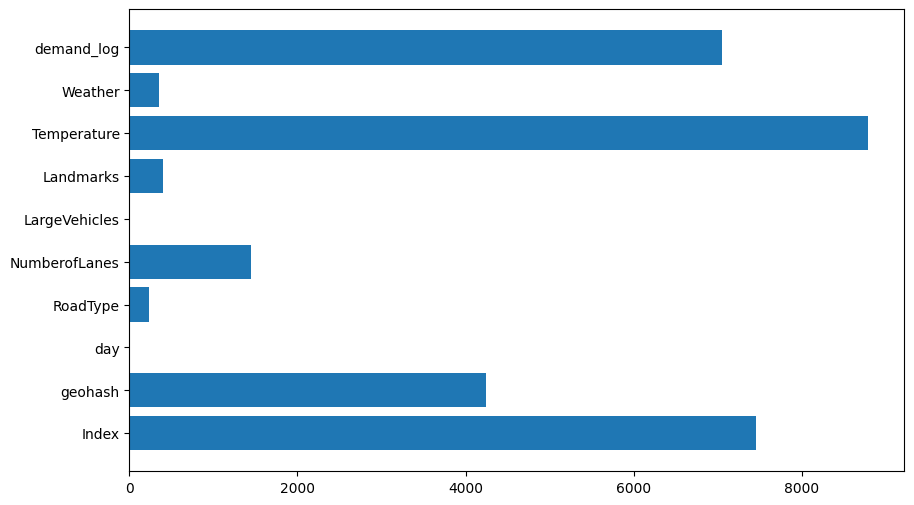

In [ ]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(10,6))

plt.barh(features, importance)

plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

print(scores.mean())

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006932 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1042
[LightGBM] [Info] Number of data points in the train set: 61839, number of used features: 10
[LightGBM] [Info] Start training from score 0.097337
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004199 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1042
[LightGBM] [Info] Number of data points in the train set: 61839, number of used features: 10
[LightGBM] [Info] Start training from score 0.091224
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004220 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enoug

In [ ]:
print("Train features:", X.columns.tolist())
print("Test features:", X_test.columns.tolist())

# Find the difference
missing = set(X.columns) - set(X_test.columns)
print("Missing from test:", missing)

Train features: ['Index', 'geohash', 'day', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather', 'demand_log']
Test features: ['Index', 'geohash', 'day', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather']
Missing from test: {'demand_log'}


In [ ]:
# Fix: align columns after encoding
X, X_test = X.align(X_test, join='left', axis=1, fill_value=0)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', lgb.LGBMRegressor())  # ← change this
])

pipeline.fit(X, y)
final_predictions = pipeline.predict(X_test) # same transforms applied automatically

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023762 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1046
[LightGBM] [Info] Number of data points in the train set: 77299, number of used features: 10
[LightGBM] [Info] Start training from score 0.093942


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd

# Example: bin into categories
y = pd.cut(y, bins=3, labels=[0, 1, 2]).astype(int)

# Or if y is already meant to be integers but stored as floats:
y = y.astype(int)

In [ ]:
print(y.dtype)         # float → likely regression
print(y.nunique())     # many unique values → regression
print(y.unique())      # e.g. [0, 1] or [0,1,2] → classification


int64
3
[0 1 2]


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb

pipeline = Pipeline([
    ('scaler', StandardScaler()),       # or your preprocessor
    ('model', lgb.LGBMClassifier())
])

pipeline.fit(X, y)
final_predictions = pipeline.predict(X_test)  # same transforms applied automatically

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016605 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1046
[LightGBM] [Info] Number of data points in the train set: 77299, number of used features: 10
[LightGBM] [Info] Start training from score -0.051839
[LightGBM] [Info] Start training from score -3.358140
[LightGBM] [Info] Start training from score -4.152937
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
print(f"X shape: {X.shape}")          # Should be (n, 10)
print(f"X_test shape: {X_test.shape}")  # Currently (m, 9) — find the gap

X shape: (77299, 10)
X_test shape: (41778, 10)


In [ ]:
model.fit(X, y)

final_predictions = model.predict(X_test)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007348 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1042
[LightGBM] [Info] Number of data points in the train set: 77299, number of used features: 10
[LightGBM] [Info] Start training from score 0.066236
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [ ]:
sample = pd.read_csv("sample_submission.csv")

print(sample.head())

   Index    demand
0      0  0.090768
1      1  0.089885
2      2  0.007037
3      3  0.079087
4      4  0.054636


In [ ]:
submission = pd.DataFrame({
    "Index": test["Index"],
    "demand": final_predictions
})

submission.to_csv(
    "submission.csv",
    index=False
)

print(submission.shape)

(41778, 2)
